In [2]:
import src.sph_cpp as sph
import struct
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Define simulation parameters

In [3]:
res = 0.5
no_steps = 100
Lx = 5.0
Ly = 5.0
rho0 = 1000.0
kappa = 1.2
v0 = 10
dt = 0.01
c_s = 0.01
gamma_index = 7.0

Run simulation

In [4]:
params = sph.SimulationParams(
    res, no_steps, Lx, Ly, rho0, kappa, v0, dt, c_s, gamma_index
)

# Initialize ParticleList
particle_list = sph.ParticleList(params)

# Setup initial conditions
particle_list.init_random()
particle_list.init_mass()
particle_list.init_vel()

# Run simulation
particle_list.integrate()

time,x,y


Read data

In [5]:
def read_all_output(filename):
    frames = []
    with open(filename, "rb") as f:
        while True:
            int_bytes = f.read(4)
            if not int_bytes:
                break  # EOF
            N = struct.unpack("i", int_bytes)[0]

            x_bytes = f.read(8 * N)
            y_bytes = f.read(8 * N)
            if len(x_bytes) < 8 * N or len(y_bytes) < 8 * N:
                print("Warning: Incomplete frame at the end of the file")
                break

            x = np.frombuffer(x_bytes, dtype=np.float64)
            y = np.frombuffer(y_bytes, dtype=np.float64)
            frames.append((x, y))

    return frames

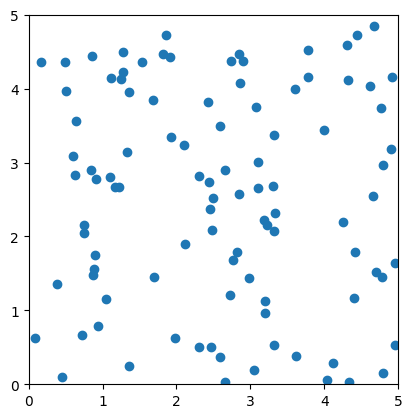

In [6]:
frames = read_all_output("all_output.bin")



idx = 1
fig, ax = plt.subplots()
particles, = ax.plot(frames[0][0], frames[0][1], linestyle="None", marker="o")
ax.set_xlim(0,5)
ax.set_ylim(0,5)
ax.set_aspect("equal")
def update(frame):
    particles.set_xdata(frames[frame][0])
    particles.set_ydata(frames[frame][1])

anim = FuncAnimation(fig, update, len(frames))
anim.save("figures/cpp_animation.mp4")
plt.show()